In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.shape

(9994, 21)

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
## Key Observations from Initial Exploration

##- **9,994 rows, 21 columns** — clean, manageable size for analysis.
##- **No missing values anywhere** — dataset is unusually clean; cleaning effort will be light.
##- **`Order Date` and `Ship Date` are stored as text**, not datetime — must fix before any time-based analysis.
##- **Red flag:** `Profit` ranges from -$6,599.98 to $8,399.98, while the average is only ~$28.66 — a few large losses may be dragging down overall profitability. Worth investigating which products/regions are responsible.
##- **Discount** goes up to 80%, avg ~15.6% — worth checking if heavy discounting is linked to the loss-making orders above.
##- **`Row ID`** is just a counter — not useful for analysis, will be dropped/ignored later.

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [8]:
## Data Cleaning: Fixing Date Columns

#`Order Date` and `Ship Date` were loaded as text (object) instead of actual dates.
#This matters because we can't do time-based analysis (monthly trends, shipping
#delays, seasonality) on text — Python needs to recognize these as real dates first.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
loss_orders = df[df['Profit'] < 0]
print(f"Number of loss-making orders: {len(loss_orders)}")
print(f"Percentage of total orders: {round(len(loss_orders)/len(df)*100, 2)}%")
print(f"Total loss amount: ${loss_orders['Profit'].sum():,.2f}")

Number of loss-making orders: 1871
Percentage of total orders: 18.72%
Total loss amount: $-156,131.29


In [11]:
loss_by_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values()
loss_by_subcategory.head(5)

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

In [12]:
print("Avg discount on LOSS-making orders:", round(df[df['Profit'] < 0]['Discount'].mean(), 3))
print("Avg discount on PROFITABLE orders:", round(df[df['Profit'] >= 0]['Discount'].mean(), 3))

Avg discount on LOSS-making orders: 0.481
Avg discount on PROFITABLE orders: 0.081


In [14]:
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()
discount_profit

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


In [15]:
# Key Insight: The Discount Tipping Point is 20%
# Average profit by discount level shows a clear break point
# Discounts from 0% to 20% keep orders profitable (avg profit ranges from ~$25 to ~$97)
# At 30% discount and above, average profit turns negative
# Losses get progressively worse up to 50% discount (avg profit as low as -$310.70)
# At 60-80% discount, losses appear slightly smaller, likely due to fewer orders at that extreme
# This is a clean, consistent pattern, not just a few

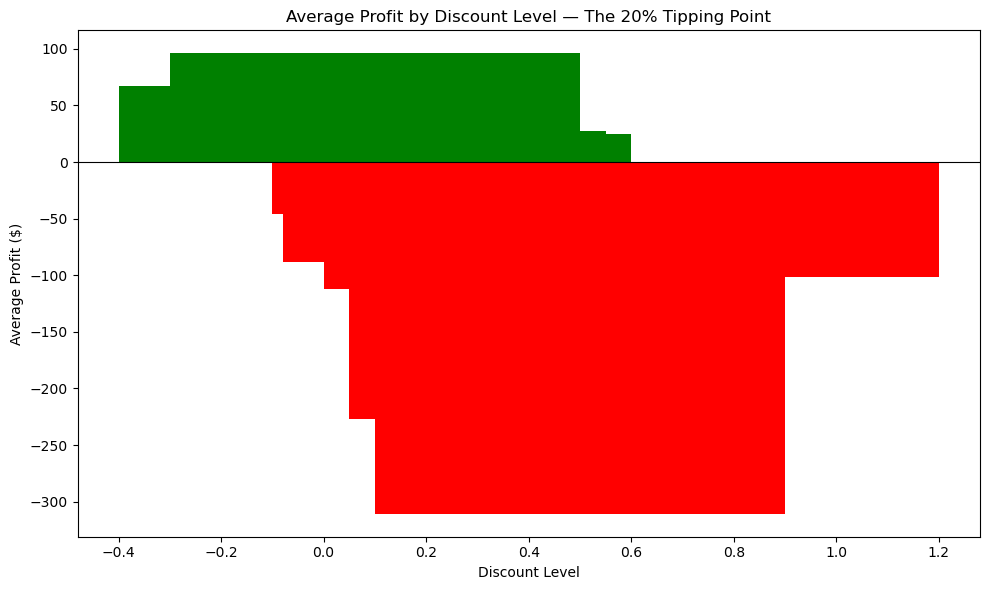

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(discount_profit['Discount'], discount_profit['Profit'], 
        color=['green' if x > 0 else 'red' for x in discount_profit['Profit']])
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Discount Level')
plt.ylabel('Average Profit ($)')
plt.title('Average Profit by Discount Level — The 20% Tipping Point')
plt.tight_layout()
plt.savefig('../images/discount_profit_tipping_point.png', dpi=150)
plt.show()

In [17]:
# Key Insight: Visualizing the Discount Tipping Point
# This chart makes the 20% discount threshold immediately visible
# Green bars (0% to 20% discount) show consistently positive average profit
# Red bars (30% discount and above) show consistently negative average profit
# The sharp color break at 20% is a strong visual argument for a discount cap policy
# This chart is a strong candidate for the README and Power BI dashboard later
# since it summarizes the entire discount-loss finding in a single glance

In [18]:
# total sales and profit by region
region_performance = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
region_performance

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [19]:
# Key Insight: Regional Performance
# West is the top-performing region on both sales ($725,458) and profit ($108,418)
# East follows closely in profit ($91,523) despite lower sales than West
# Central is the weakest region — highest sales among the bottom two ($501,240)
# but lowest profit of all regions ($39,706), suggesting a profitability problem,
# not a sales volume problem
# Business question: does Central have higher discounting or more Table/Bookcase
# sales, which we already know are loss-drivers? Worth checking next

In [20]:
# total sales and profit by category
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
category_performance

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


In [21]:
# Key Insight: Furniture is the Weak Link
# Furniture has almost identical sales to Office Supplies ($741,999 vs $719,047)
# but drastically lower profit ($18,451 vs $122,491) — nearly 7x less profit
# despite similar revenue
# This strongly aligns with our earlier finding: Tables and Bookcases
# (both Furniture sub-categories) were the biggest loss-makers
# Technology is the strongest performer — highest sales AND highest profit,
# suggesting healthy margins with less reliance on heavy discounting
# Business recommendation: Furniture's discount policy needs the most urgent review,
# since its revenue looks healthy but its profit does not

In [22]:
# check average discount by category — confirming if Furniture is over-discounted
category_discount = df.groupby('Category')['Discount'].mean().sort_values(ascending=False)
category_discount

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

In [23]:
# check average discount by region — confirming if Central is over-discounted
region_discount = df.groupby('Region')['Discount'].mean().sort_values(ascending=False)
region_discount

Region
Central    0.240353
South      0.147253
East       0.145365
West       0.109335
Name: Discount, dtype: float64

In [24]:
# Key Insight: Discounting Confirmed as the Root Cause
# Furniture has the highest average discount of all categories (17.4%),
# compared to Office Supplies (15.7%) and Technology (13.2%)
# This confirms Furniture's low profit is driven by discounting, not weak demand
# Central region has the highest average discount by far (24.0%),
# nearly double West's discount rate (10.9%)
# This directly explains why Central has the lowest profit despite decent sales,
# and why West is the strongest-performing region overall
# Conclusion: discounting behavior, not sales volume, is the primary driver
# of profit differences across both categories and regions
# Business recommendation: apply the 20% discount cap most strictly to
# Furniture and Central region, where over-discounting is most severe

In [25]:
# top 10 products by total profit
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [26]:
# bottom 10 products by total profit (biggest losers)
bottom_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
bottom_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [27]:
# Key Insight: Product-Level Winners and Losers
# Top performer: Canon imageCLASS 2200 Advanced Copier generated $25,199 profit alone,
# nearly 3x more than the second-best product
# Most top 10 products are Technology items (copiers, printers, binding machines),
# confirming Technology's strength as the most profitable category
# Biggest single loss: Cubify CubeX 3D Printer Double Head Print, at -$8,879
# Two 3D printer variants from the same product line appear in the bottom 3,
# suggesting this specific product line is structurally unprofitable, not just
# a discounting issue
# Confirms Furniture problem at product level: Conference Tables and Round Tables
# appear multiple times in the bottom 10, consistent with our earlier finding
# that Tables sub-category is the biggest loss-driver
# Business recommendation: investigate whether Cubify 3D Printers should be
# discontinued or repriced — their losses are too large to be explained by
# discounting alone and may indicate a fundamentally unprofitable product

In [28]:
# monthly sales and profit trend
df['OrderMonth'] = df['Order Date'].dt.to_period('M')
monthly_trend = df.groupby('OrderMonth')[['Sales', 'Profit']].sum()
monthly_trend.tail(12)

,Sales,Profit
OrderMonth,,
2017-01,43971.3740,7140.4391
2017-02,20301.1334,1613.8720
2017-03,58872.3528,14751.8915
2017-04,36521.5361,933.2900
2017-05,44261.1102,6342.5828
2017-06,52981.7257,8223.3357
2017-07,45264.4160,6952.6212
2017-08,63120.8880,9040.9557
2017-09,87866.6520,10991.5556


In [29]:
# Key Insight: 2017 Monthly Trend Shows Growth with a Profit Warning Sign
# Overall sales trend upward across 2017, peaking in November ($118,448) —
# likely holiday season demand (Black Friday / Cyber Monday effect)
# However, November's profit ($9,690) is not proportionally as high as its sales,
# especially compared to March, which had far lower sales ($58,872) but
# comparable profit ($14,752) — March had a much healthier profit margin
# April stands out as a weak month: sales were decent ($36,522) but profit
# dropped to just $933, the lowest of the year — worth checking April's
# discount levels and category mix as a follow-up
# Business question: is November's holiday sales spike being driven by heavy
# discounting (consistent with our earlier finding that discounts above 20%
# erode profit)? This would mean the "biggest sales month" isn't the
# "best month" for the business

In [30]:
# check average discount in November vs March to test the holiday-discounting theory
nov_discount = df[df['OrderMonth'] == '2017-11']['Discount'].mean()
mar_discount = df[df['OrderMonth'] == '2017-03']['Discount'].mean()
print(f"November avg discount: {nov_discount:.3f}")
print(f"March avg discount: {mar_discount:.3f}")

November avg discount: 0.161
March avg discount: 0.131


In [31]:
# Profit Margin % — tells us how efficient each order is, not just how big
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Shipping Duration — days between order and shipment, useful for operations analysis
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Order Size Category — buckets orders into Small/Medium/Large based on Sales value
df['Order Size'] = pd.cut(df['Sales'], 
                            bins=[0, 50, 200, float('inf')], 
                            labels=['Small', 'Medium', 'Large'])

# Is Loss-Making — a simple flag column, useful for quick filtering in SQL/Power BI later
df['Is Loss'] = df['Profit'] < 0

df[['Sales', 'Profit', 'Profit Margin', 'Shipping Duration', 'Order Size', 'Is Loss']].head()

,Sales,Profit,Profit Margin,Shipping Duration,Order Size,Is Loss
0,261.9600,41.9136,16.00,3,Large,False
1,731.9400,219.5820,30.00,3,Large,False
2,14.6200,6.8714,47.00,4,Small,False
3,957.5775,-383.0310,-40.00,7,Large,True
4,22.3680,2.5164,11.25,7,Small,False


In [32]:
# save the cleaned + feature-engineered dataset to the processed folder
df.to_csv('../data/processed/superstore_cleaned.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [34]:
# convert OrderMonth from Pandas Period type to plain text (string)
# SQL databases don't understand the Period data type, so we convert it first
df['OrderMonth'] = df['OrderMonth'].astype(str)

In [35]:
import sqlite3

conn = sqlite3.connect('../data/processed/superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

print("Database created and data loaded successfully!")

Database created and data loaded successfully!


In [36]:
test_query = "SELECT COUNT(*) as total_orders FROM orders"
pd.read_sql(test_query, conn)

,total_orders
0,9994


In [ ]:
# Key Insight / Note: Database Verified
# Test query confirms all 9,994 orders loaded correctly into the SQLite database
# The 'orders' table now contains every column, including engineered features
# (Profit Margin, Shipping Duration, Order Size, Is Loss), ready for SQL analysis